v2: clean V1 and organise plots

In [4]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras import backend as K
#from sklearn import preprocessing
from importlib import reload
import matplotlib as mpl
import scipy
import os

sys.path.insert(0,'../../scripts/tools_for_VAE/')
import tools_for_VAE.model
from tools_for_VAE import utils, vae_functions, generator, model, boxplot, plot

%matplotlib inline
%config InlineBackend.figure_format='retina'

W0707 16:12:45.820982 139969081292608 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:88: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
from platform import python_version

print(python_version())
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Lambda, Layer, Multiply, Reshape, Flatten, BatchNormalization, Conv2D, Conv3D, UpSampling2D, Cropping2D, Conv2DTranspose, PReLU, Concatenate, Lambda,  concatenate
import tensorflow_probability as tfp

3.6.8


In [3]:
######## Parameters
nb_of_bands = 6
batch_size = 256

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

## Load data

In [6]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

In [7]:
1/(0.063*1.65)

9.62000962000962

In [8]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/' # mag cut at 24.5 in r band

images_noiseless = np.load(root_dir_v1+'img_noiseless_sample_2.npy', mmap_mode = 'c') # artificial augmentation of pixel intensity. Residual from tests, needs to be suppressed
images_blend = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])

ellipticity = calc_lensed_ellipticity(-ell_1, ell_2, -shear_1, shear_2, convergence)
ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

e1 = ellipticity_conversion(calc_lensed_ellipticity_1(-ell_1, ell_2, -shear_1, shear_2, convergence))
e2 = ellipticity_conversion(calc_lensed_ellipticity_2(-ell_1, ell_2, -shear_1, shear_2, convergence))

In [21]:
np.mean(np.sqrt(e1**2+e2**2)), np.mean(e1), np.mean(e2)

(0.26621964499139505, -0.001265548531133095, -0.005320479260479739)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
id                10000 non-null int64
e1                10000 non-null float64
e2                10000 non-null float64
shear_1           10000 non-null float64
shear_2           10000 non-null float64
redshift          10000 non-null float64
redshift_true     10000 non-null float64
blendedness       9999 non-null float64
snr_r             9998 non-null float64
convergence       10000 non-null float64
e1_hsm_regauss    9976 non-null float64
e2_hsm_regauss    9976 non-null float64
mag_r_meas        9998 non-null float64
mag_r_true        10000 non-null float64
dtypes: float64(13), int64(1)
memory usage: 1.1 MB


# Param estimation from trained VAE

## Load VAE model and create parameter estimation network

In [7]:
vae = model.create_model_wo_ls_peak_pooling_vae_4(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0619 19:37:55.481108 140323544405824 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W0619 19:37:55.979030 140323544405824 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.


in cropping


In [8]:
encoder = Model([vae.layers[0].input,vae.layers[-2].input], vae.layers[20].output) #vae.layers[44].output[0]

In [26]:
input_layer_1 = Input(shape=(2)) 
h = Dense(5, use_bias = True)(input_layer_1)
h= Dense(1)(h)

model = Model(input_layer_1,h)
model.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_3 (InputLayer)         [(None, 2)]               0         
_________________________________________________________________
dense_2 (Dense)              (None, 5)                 15        
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 6         
Total params: 21
Trainable params: 21
Non-trainable params: 0
_________________________________________________________________


In [24]:
print(model.layers)

[<tensorflow.python.keras.engine.input_layer.InputLayer object at 0x7f6851ce5160>, <tensorflow.python.keras.layers.core.Dense object at 0x7f6851d55048>, <tensorflow.python.keras.layers.core.Dense object at 0x7f69ab89ed30>]


In [9]:
tfd = tfp.distributions
tfb = tfp.bijectors
encoded_size = 32
prior = tfd.Independent(tfd.Normal(loc=tf.zeros(32), scale=1.),reinterpreted_batch_ndims=1)


def param_estimation_net(vae, encoder, final_dim):
    input_layer_1 = Input(shape=(input_shape)) 
    input_layer_2 = Input(shape=(input_shape)) 
    
    encoder.trainable = False
    h = encoder([input_layer_1,input_layer_2])
    h = PReLU()(h)
    
    h = Dense(tfp.layers.MultivariateNormalTriL.params_size(final_dim),activation=None)(h)
    h = tfp.layers.MultivariateNormalTriL(final_dim)(h)
    
    return Model((input_layer_1, input_layer_2), h)

In [10]:
param_estim_net = param_estimation_net(vae, encoder, final_dim)

In [11]:
param_estim_net.summary()

Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
input_4 (InputLayer)            [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
model_1 (Model)                 (None, 560)          3741224     input_3[0][0]                    
                                                                 input_4[0][0]                    
__________________________________________________________________________________________________
p_re_lu_20 (PReLU)              (None, 560)          560         model_1[1][0]              

## Model with weighting

### Load weights

In [12]:
loading_path = '/pbs/home/b/barcelin/sps_link/TFP/weights/test_dc2/v_param_from_vae_nf/loss/'

In [13]:
latest = tf.train.latest_checkpoint(loading_path)
param_estim_net.load_weights(latest)

### Test

In [16]:
e1_out_mean = []
e2_out_mean = []

e1_out_std = []
e2_out_std = []

images_blend_temp = np.tanh(np.arcsinh(images_blend[9000:10000]))
psf_temp = np.tanh(np.arcsinh(psf[9000:10000]))
print('images temp OK ')
output = param_estim_net([tf.cast(images_blend_temp, tf.float32), tf.cast(psf_temp, tf.float32)])
print('output OK ')
#del images_blend_temp, psf_temp

print(output)
mean = K.get_value(output.mean())
std = K.get_value(output.stddev())

print('get value OK')
e1_out_mean = mean[:,0]
e2_out_mean = mean[:,1]

e1_out_std = std[:,0]
e2_out_std = std[:,1]

del  images_blend_temp, psf_temp, output, mean, std

images temp OK 
output OK 
tfp.distributions.MultivariateNormalTriL("model_2_1_multivariate_normal_tri_l_1_MultivariateNormalTriL_MultivariateNormalTriL", batch_shape=[1000], event_shape=[2], dtype=float32)
get value OK


In [17]:
df = pd.DataFrame()

df['e1_out_mean'] = e1_out_mean
df['e2_out_mean'] = e2_out_mean
df['e1_out_std'] = e1_out_std
df['e2_out_std'] = e2_out_std

df.to_csv('data/df_param_from_vae_4.csv')

In [4]:
part_1 = pd.read_csv('data/df_param_from_vae_1.csv', encoding = 'utf-8')
part_2 = pd.read_csv('data/df_param_from_vae_2.csv', encoding = 'utf-8')
part_3 = pd.read_csv('data/df_param_from_vae_3.csv', encoding = 'utf-8')
part_4 = pd.read_csv('data/df_param_from_vae_4.csv', encoding = 'utf-8')

df_plot = pd.concat([part_1,part_2, part_3, part_4], ignore_index = True)

Text(0.5, 1.0, '$e2$')

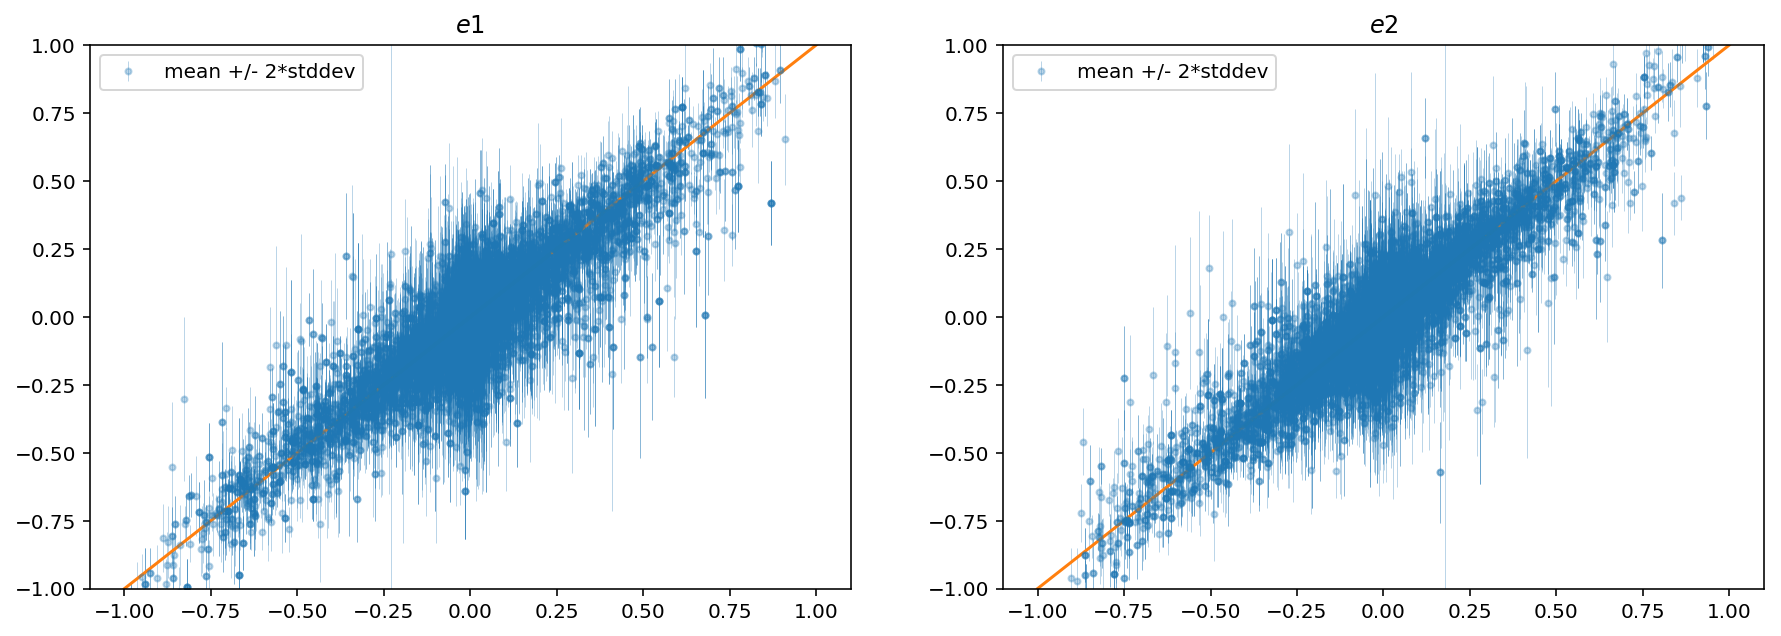

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(-e1, df_plot['e1_out_mean'], yerr = df_plot['e1_out_std'],  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
axes[0].set_ylim(-1,1)
axes[0].set_title('$e1$')

axes[1].errorbar(e2, df_plot['e2_out_mean'], yerr = df_plot['e2_out_std'],  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev', alpha = 0.3)
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-1,1)
axes[1].set_title('$e2$')

In [9]:
df = pd.DataFrame()

d = pd.DataFrame()
d['e1'] = df_plot['e1_out_mean']
d['e2'] = df_plot['e2_out_mean']
d['e1_std'] = df_plot['e1_out_std']
d['e2_std'] = df_plot['e2_out_std']
d['e1_in'] = -e1
d['e2_in'] = e2
d['e_in'] = np.sqrt(d['e1_in']**2+d['e2_in']**2)

df['e_1'] = pd.concat([d['e1'],data['e1_hsm_regauss']], ignore_index = True)#, ignore_index=True, sort = True)
df['e_2'] = pd.concat([d['e2'],data['e2_hsm_regauss']], ignore_index = True)
df['e'] = pd.concat([np.sqrt(d['e1']**2+d['e2']**2),np.sqrt(data['e1_hsm_regauss']**2+data['e2_hsm_regauss']**2)], ignore_index = True)
df['e_in'] = pd.concat([d['e_in'],d['e_in']], ignore_index = True)
df['e_error_reg'] = df['e']-df['e_in']
#df['e_1_hsm'] = data['e1_hsm_regauss'][indices]
#df['e_2_hsm'] = data['e2_hsm_regauss'][indices]
#df['e_hsm'] = np.sqrt(df['e_1_hsm']**2+df['e_2_hsm']**2)

df['blendedness'] = pd.concat([data['blendedness'],data['blendedness']], ignore_index = True)
df['snr_r'] = pd.concat([data['snr_r'],data['snr_r']], ignore_index = True)

df['exp'] = [1]*10000+[2]*10000

In [27]:
df_plot_2 = df[df['blendedness']>0]

16170
[1 2]
0 1
1 2


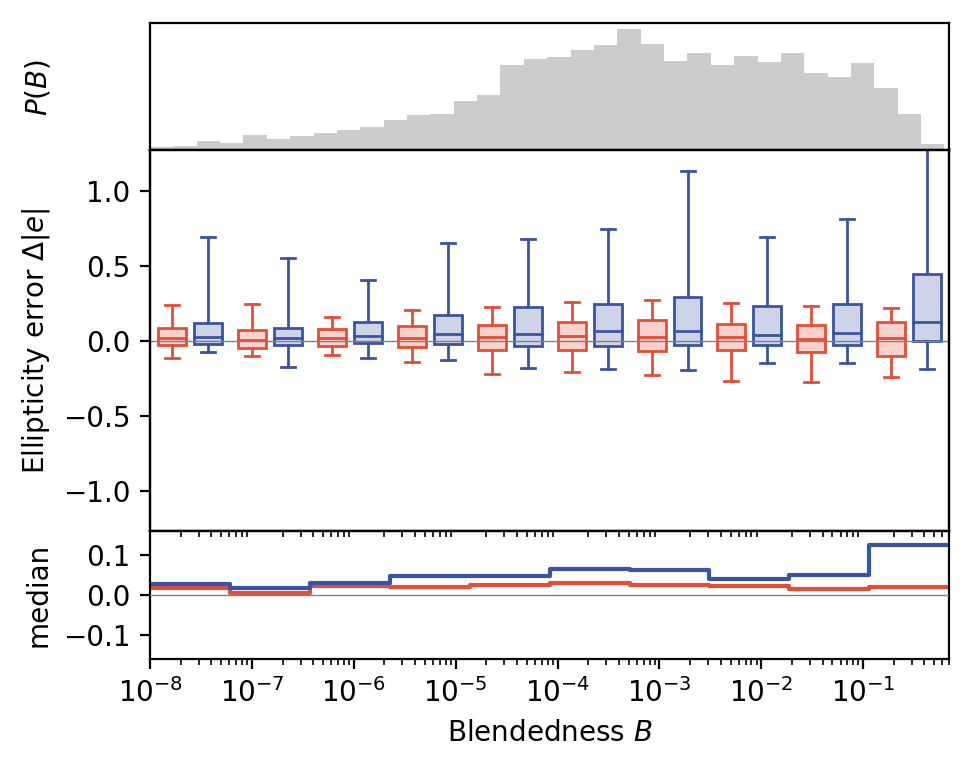

In [32]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['param estimation network', 'LSST pipeline'],
              x_label='Blendedness $B$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(B)$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)

fig.savefig('imgs/e_blend_dc2_from_vae_hsm.pdf')

In [33]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
df_stat['stats_names'] = ['network']*10 + ['pipeline']*10

x = 10

In [34]:
df_stat

,median_shear,q1_shear,q3_shear,whislo_shear,whishi_shear,stats_names
0,0.017235,0.030422,0.084135,0.111101,0.241685,network
1,0.005922,0.044246,0.075809,0.098389,0.244195,network
2,0.022641,0.031182,0.079128,0.095221,0.157546,network
3,0.020317,0.043231,0.102410,0.139236,0.202850,network
4,0.024578,0.059602,0.106901,0.221424,0.223696,network
5,0.029807,0.061469,0.129073,0.206039,0.256584,network
6,0.024053,0.070263,0.139045,0.227794,0.275284,network
7,0.023573,0.061559,0.109796,0.264535,0.249558,network
8,0.014315,0.071790,0.107237,0.272134,0.234004,network
9,0.019813,0.101161,0.126910,0.240815,0.221076,network


In [1]:
np.std(df_stat['median_shear'][:10]), np.mean(df_stat['median_shear'][:10])

NameError: name 'np' is not defined

In [35]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][:+x]) ]))

mean for each exp: [0.020225379578852766, 0.051497621612620226]
improvement between each exp: [2.546188140096271]


19974
[1 2]
0 1
1 2


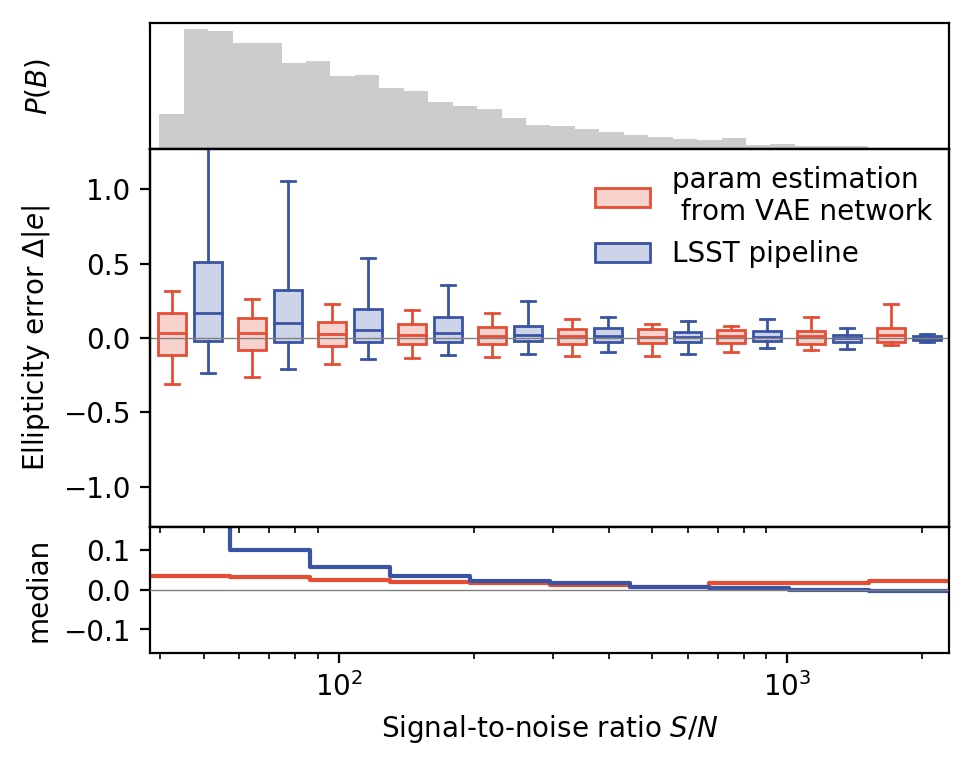

In [31]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df, x = 'snr_r', y = 'e_error_reg', z = 'exp',
              xlim = (38, 2300),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['param estimation \n from VAE network', 'LSST pipeline'],
              x_label='Signal-to-noise ratio $S/N$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(S/N)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)

fig.savefig('imgs/e_snr_dc2_from_vae_hsm.pdf')

In [26]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 + ['pipeline']*10

x = 10

In [27]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][:+x]) ]))

mean for each exp: [0.019816815075623963, 0.04118391291670724]
improvement between each exp: [2.0782306722620763]


/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/ipykernel_launcher.py:11: UserWarning: Attempted to set non-positive left xlim on a log-scaled axis.
Invalid limit will be ignored.
  # This is added back by InteractiveShellApp.init_path()
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/ipykernel_launcher.py:12: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  if sys.path[0] == '':


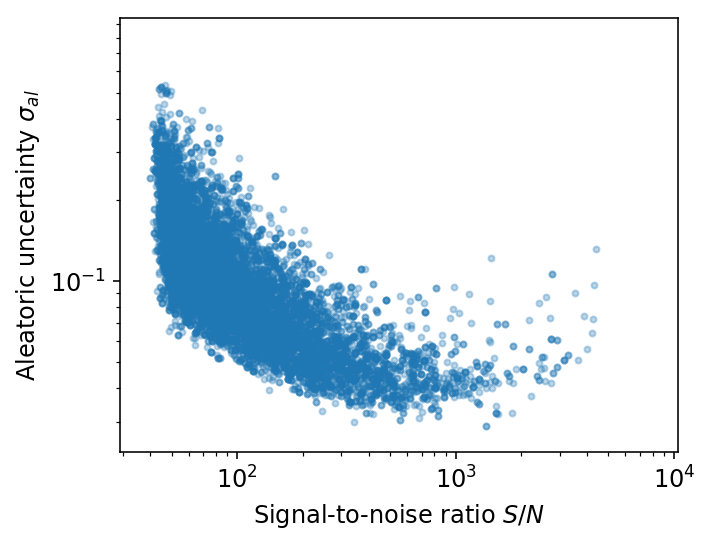

In [14]:
import matplotlib#plt.hist2d(data['snr_r'], d['e1_std'], bins = 10)
fig, axes = plt.subplots(1,1, figsize= (5,4))
font = {'family' : 'normal',
        'size'   : 12}

matplotlib.rc('font', **font)

axes.plot(data['snr_r'], d['e1_std'], '.', alpha = 0.3)
axes.set_xscale('log')
axes.set_yscale('log')
axes.set_xlim(0,10500)
axes.set_ylim(0,0.95)

axes.set_xlabel('Signal-to-noise ratio $S/N$')
axes.set_ylabel('Aleatoric uncertainty $\sigma_{al}$')

fig.savefig('imgs/sigma_al_param_from_vae.pdf')

In [24]:
np.min(d['e1_std'])

KeyError: 'e1_std'

In [28]:
import numpy as np
import scipy.stats as stats
import math

mu = 0
variance = 1
sigma = math.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
#plt.plot(x, stats.norm.pdf(x, mu, sigma))
#plt.show()

/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/font_manager.py:1241: UserWarning: findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
  (prop.get_family(), self.defaultFamily[fontext]))


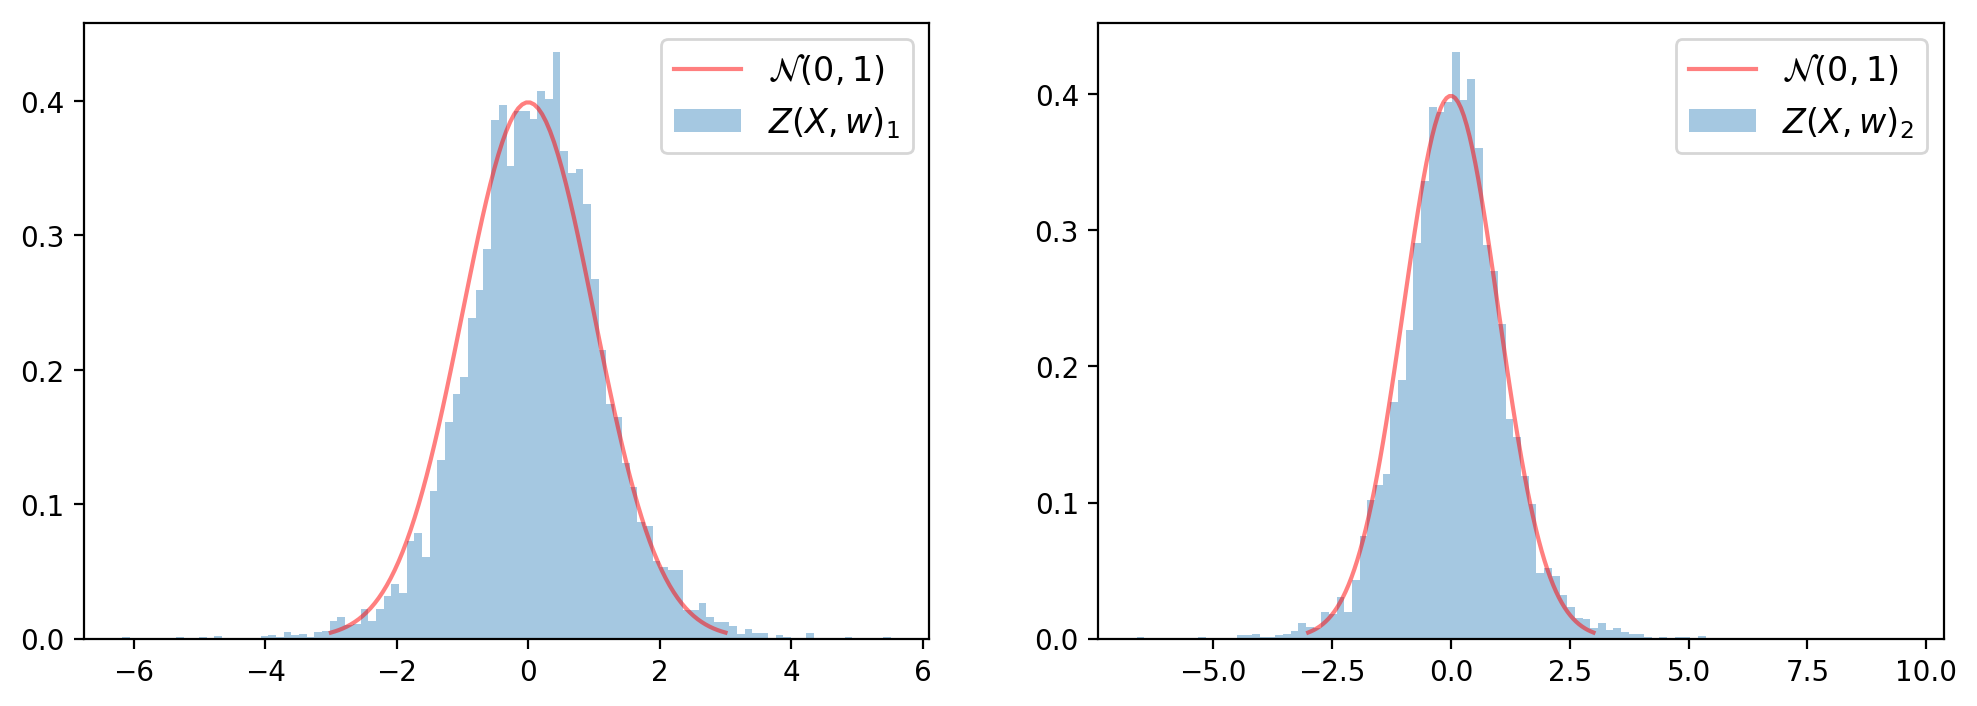

In [29]:
import matplotlib
fig, axes = plt.subplots(1,2, figsize =(12,4))
font = {'family' : 'normal',
        'size'   : 12}

matplotlib.rc('font', **font)

_ = axes[0].hist((d['e1_in']-d['e1'])/d['e1_std'], bins = 100, normed = True, alpha = 0.4, label='$Z(X,w)_1$')
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), label = '$\mathcal{N}(0,1)$', color = 'red', alpha = 0.5)
axes[0].legend()
#axes[0].set_title

_ = axes[1].hist((d['e2_in']-d['e2'])/d['e2_std'], bins = 100, normed = True, alpha = 0.4, label='$Z(X,w)_2$')
axes[1].plot(x, stats.norm.pdf(x, mu, sigma), label = '$\mathcal{N}(0,1)$', color = 'red', alpha = 0.5)
axes[1].legend()
#axes[0].set_title

fig.savefig('imgs/distrib_al_param_from_vae.pdf')

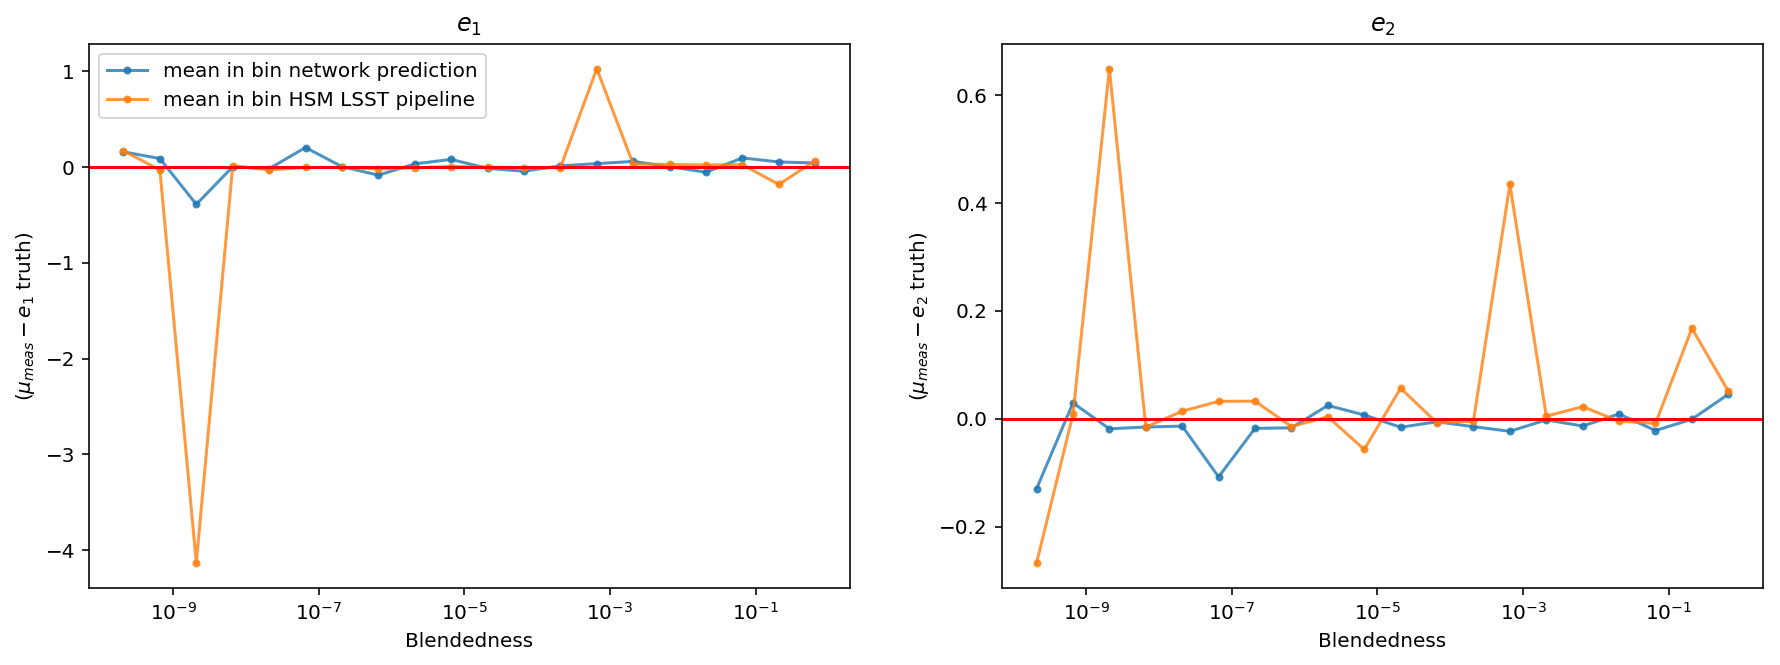

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
nbins = 20

bins=np.logspace(np.log10(1e-10),np.log10(1), nbins+1)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e1_out_mean+e1[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(nbins)
for k in range(nbins):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

#axes[0].plot(data['blendedness'][indices], (e1_out_mean+e1[indices]), '.',label = 'mean prediction', alpha = 0.2)
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin network prediction')

bins=np.logspace(np.log10(1e-10),np.log10(1), nbins+1)

bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (data['e1_hsm_regauss'][indices]-e1[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(nbins)
for k in range(nbins):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes[0].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin HSM LSST pipeline')


axes[0].axhline(0, color = 'r')
axes[0].set_title('$e_1$')
axes[0].set_ylabel('($\mu_{meas} - e_1$ truth)')
axes[0].set_xlabel('Blendedness')
axes[0].set_xscale('log')
#axes[0].set_ylim(-2,2)

bins=np.logspace(np.log10(1e-10),np.log10(1), nbins+1)
bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (e2_out_mean-e2[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(nbins)
for k in range(nbins):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2

#axes[1].plot(data['blendedness'][indices], (e2_out_mean-e2[indices]), '.',label = 'mean prediction', alpha = 0.2)
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin HSM LSST pipeline')

bins=np.logspace(np.log10(1e-10),np.log10(1), nbins+1)

bin_means, bin_edges, binnumber = scipy.stats.binned_statistic(data['blendedness'][indices], (data['e2_hsm_regauss'][indices]-e2[indices]), statistic='mean', bins=bins)
bin_centers = np.zeros(nbins)
for k in range(nbins):
    bin_centers[k] = bin_edges[k]+(bin_edges[k+1]-bin_edges[k])/2
axes[1].plot(bin_centers,bin_means, marker = '.',linestyle = '-', alpha = 0.8, label = 'mean in bin HSM LSST pipeline')


axes[1].axhline(0, color = 'r')
axes[1].set_title('$e_2$')
axes[1].set_ylabel('($\mu_{meas} - e_2$ truth)')
axes[1].set_xscale('log')
axes[1].set_xlabel('Blendedness')
axes[0].legend()

## Model without weighting

### Load weights

In [12]:
loading_path = '/pbs/home/b/barcelin/sps_link/TFP/weights/test_dc2/v_param_from_vae_nf_no_weights/loss/'

In [13]:
latest = tf.train.latest_checkpoint(loading_path)
param_estim_net.load_weights(latest)

### Test

In [16]:
e1_out_mean = []
e2_out_mean = []

e1_out_std = []
e2_out_std = []

images_blend_temp = np.tanh(np.arcsinh(images_blend[9000:10000]))
psf_temp = np.tanh(np.arcsinh(psf[9000:10000]))
print('images temp OK ')
output = param_estim_net([tf.cast(images_blend_temp, tf.float32), tf.cast(psf_temp, tf.float32)])
print('output OK ')
#del images_blend_temp, psf_temp

print(output)
mean = K.get_value(output.mean())
std = K.get_value(output.stddev())

print('get value OK')
e1_out_mean = mean[:,0]
e2_out_mean = mean[:,1]

e1_out_std = std[:,0]
e2_out_std = std[:,1]

del  images_blend_temp, psf_temp, output, mean, std

images temp OK 
output OK 
tfp.distributions.MultivariateNormalTriL("model_2_1_multivariate_normal_tri_l_1_MultivariateNormalTriL_MultivariateNormalTriL", batch_shape=[1000], event_shape=[2], dtype=float32)
get value OK


In [17]:
df = pd.DataFrame()

df['e1_out_mean'] = e1_out_mean
df['e2_out_mean'] = e2_out_mean
df['e1_out_std'] = e1_out_std
df['e2_out_std'] = e2_out_std

df.to_csv('data/df_param_from_vae_no_weighting_4.csv')

In [15]:
part_1 = pd.read_csv('data/df_param_from_vae_no_weighting_1.csv', encoding = 'utf-8')
part_2 = pd.read_csv('data/df_param_from_vae_no_weighting_2.csv', encoding = 'utf-8')
part_3 = pd.read_csv('data/df_param_from_vae_no_weighting_3.csv', encoding = 'utf-8')
part_4 = pd.read_csv('data/df_param_from_vae_no_weighting_4.csv', encoding = 'utf-8')

df_plot = pd.concat([part_1,part_2, part_3, part_4], ignore_index = True)

In [16]:
df = pd.DataFrame()

d = pd.DataFrame()
d['e1'] = df_plot['e1_out_mean']
d['e2'] = df_plot['e2_out_mean']
d['e1_std'] = df_plot['e1_out_std']
d['e2_std'] = df_plot['e2_out_std']
d['e1_in'] = -e1
d['e2_in'] = e2
d['e_in'] = np.sqrt(d['e1_in']**2+d['e2_in']**2)

df['e_1'] = pd.concat([d['e1'],data['e1_hsm_regauss']], ignore_index = True)#, ignore_index=True, sort = True)
df['e_2'] = pd.concat([d['e2'],data['e2_hsm_regauss']], ignore_index = True)
df['e'] = pd.concat([np.sqrt(d['e1']**2+d['e2']**2),np.sqrt(data['e1_hsm_regauss']**2+data['e2_hsm_regauss']**2)], ignore_index = True)
df['e_in'] = pd.concat([d['e_in'],d['e_in']], ignore_index = True)
df['e_error_reg'] = df['e']-df['e_in']
#df['e_1_hsm'] = data['e1_hsm_regauss'][indices]
#df['e_2_hsm'] = data['e2_hsm_regauss'][indices]
#df['e_hsm'] = np.sqrt(df['e_1_hsm']**2+df['e_2_hsm']**2)

df['blendedness'] = pd.concat([data['blendedness'],data['blendedness']], ignore_index = True)
df['snr_r'] = pd.concat([data['snr_r'],data['snr_r']], ignore_index = True)

df['exp'] = [1]*10000+[2]*10000

In [20]:
df_plot_2 = df[df['blendedness']>0]

16170
[1 2]
0 1
1 2


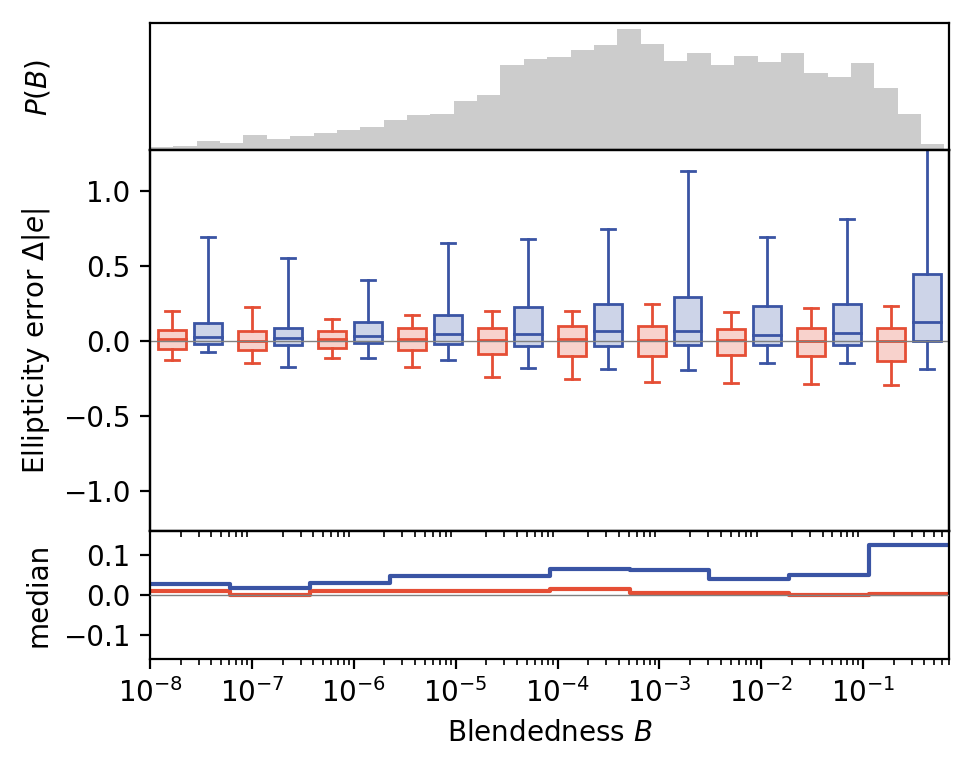

In [21]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['param estimation network', 'LSST pipeline'],
              x_label='Blendedness $B$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(B)$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15, 0.95]),
              nbins = 10)

#fig.savefig('imgs/e_blend_dc2_from_vae_hsm.pdf')

/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/ipykernel_launcher.py:11: UserWarning: Attempted to set non-positive left xlim on a log-scaled axis.
Invalid limit will be ignored.
  # This is added back by InteractiveShellApp.init_path()
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/ipykernel_launcher.py:12: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  if sys.path[0] == '':


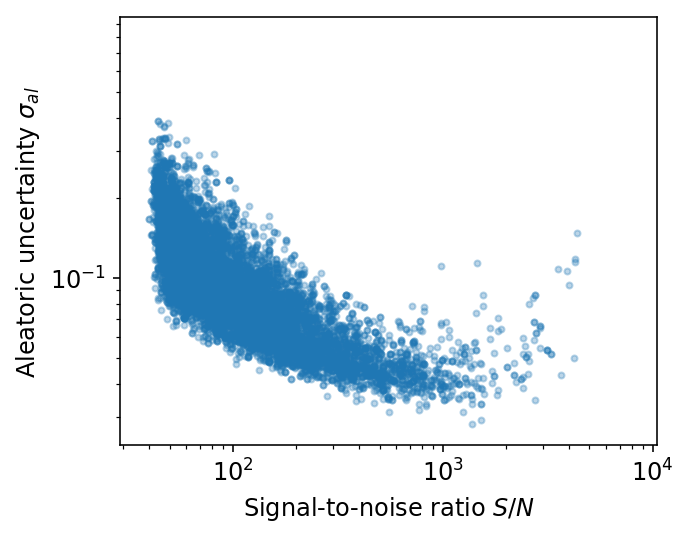

In [19]:
import matplotlib#plt.hist2d(data['snr_r'], d['e1_std'], bins = 10)
fig, axes = plt.subplots(1,1, figsize= (5,4))
font = {'family' : 'normal',
        'size'   : 12}

matplotlib.rc('font', **font)

axes.plot(data['snr_r'], d['e1_std'], '.', alpha = 0.3)
axes.set_xscale('log')
axes.set_yscale('log')
axes.set_xlim(0,10500)
axes.set_ylim(0,0.95)

axes.set_xlabel('Signal-to-noise ratio $S/N$')
axes.set_ylabel('Aleatoric uncertainty $\sigma_{al}$')

fig.tight_layout()

fig.savefig('imgs/sigma_al_param_from_vae.pdf')

## Comparison of with and without weighting

In [4]:
part_1 = pd.read_csv('data/df_param_from_vae_1.csv', encoding = 'utf-8')
part_2 = pd.read_csv('data/df_param_from_vae_2.csv', encoding = 'utf-8')
part_3 = pd.read_csv('data/df_param_from_vae_3.csv', encoding = 'utf-8')
part_4 = pd.read_csv('data/df_param_from_vae_4.csv', encoding = 'utf-8')

df_plot_weighting = pd.concat([part_1,part_2, part_3, part_4], ignore_index = True)

part_1 = pd.read_csv('data/df_param_from_vae_no_weighting_1.csv', encoding = 'utf-8')
part_2 = pd.read_csv('data/df_param_from_vae_no_weighting_2.csv', encoding = 'utf-8')
part_3 = pd.read_csv('data/df_param_from_vae_no_weighting_3.csv', encoding = 'utf-8')
part_4 = pd.read_csv('data/df_param_from_vae_no_weighting_4.csv', encoding = 'utf-8')

df_plot_no_weighting = pd.concat([part_1,part_2, part_3, part_4], ignore_index = True)

In [28]:
df = pd.DataFrame()

d = pd.DataFrame()
d['e1_weighting'] = df_plot_weighting['e1_out_mean']
d['e2_weighting'] = df_plot_weighting['e2_out_mean']
d['e1_std_weighting'] = df_plot_weighting['e1_out_std']
d['e2_std_weighting'] = df_plot_weighting['e2_out_std']
d['e1_no_weighting'] = df_plot_no_weighting['e1_out_mean']
d['e2_no_weighting'] = df_plot_no_weighting['e2_out_mean']
d['e1_std_no_weighting'] = df_plot_no_weighting['e1_out_std']
d['e2_std_no_weighting'] = df_plot_no_weighting['e2_out_std']
d['e1_in'] = -e1
d['e2_in'] = e2
d['e_in'] = np.sqrt(d['e1_in']**2+d['e2_in']**2)

df['e_1'] = pd.concat([d['e1_weighting'],d['e1_no_weighting']], ignore_index = True)#,data['e1_hsm_regauss']
df['e_2'] = pd.concat([d['e2_weighting'],d['e2_no_weighting']], ignore_index = True)#,data['e2_hsm_regauss']
df['e'] = pd.concat([np.sqrt(d['e1_weighting']**2+d['e2_weighting']**2),np.sqrt(d['e1_no_weighting']**2+d['e2_no_weighting']**2)], ignore_index = True)#,np.sqrt(data['e1_hsm_regauss']**2+data['e2_hsm_regauss']**2)
df['e_in'] = pd.concat([d['e_in'],d['e_in'],d['e_in']], ignore_index = True)
df['e_error_reg'] = df['e']-df['e_in']

df['blendedness'] = pd.concat([data['blendedness'],data['blendedness']], ignore_index = True)#,data['blendedness']
df['snr_r'] = pd.concat([data['snr_r'],data['snr_r']], ignore_index = True)#,data['snr_r']

df['exp'] = [1]*10000+[2]*10000#+[3]*10000

In [29]:
df_plot_2 = df[df['blendedness']>0]

16190
[1 2]
0 1
1 2


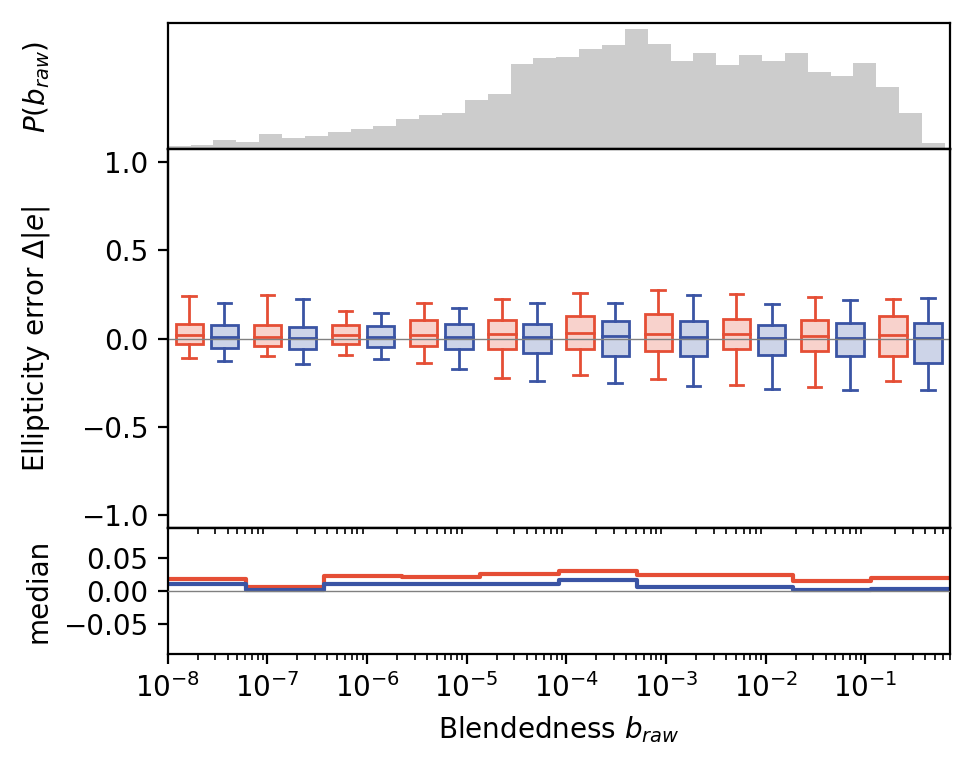

In [36]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-1.07, 1.07),
              ylim2= (-0.095, 0.095),
              x_scale = 'log',
              legend = ['weighting', 'no_weighting'],#, 'LSST pipeline'
              x_label='Blendedness $b_{raw}$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(b_{raw})$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15,0.95]),#, 0.95
              nbins = 10)

fig.savefig('imgs/e_blend_weighting.pdf')

In [12]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 + ['pipeline']*10

x = 10

In [13]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][:+x])/np.mean(df_stat[param][10:10+x]) ]))

mean for each exp: [0.020225379578852766, 0.007026599536507888]
improvement between each exp: [2.8784022020563973]


16190
[1 2]
0 1
1 2


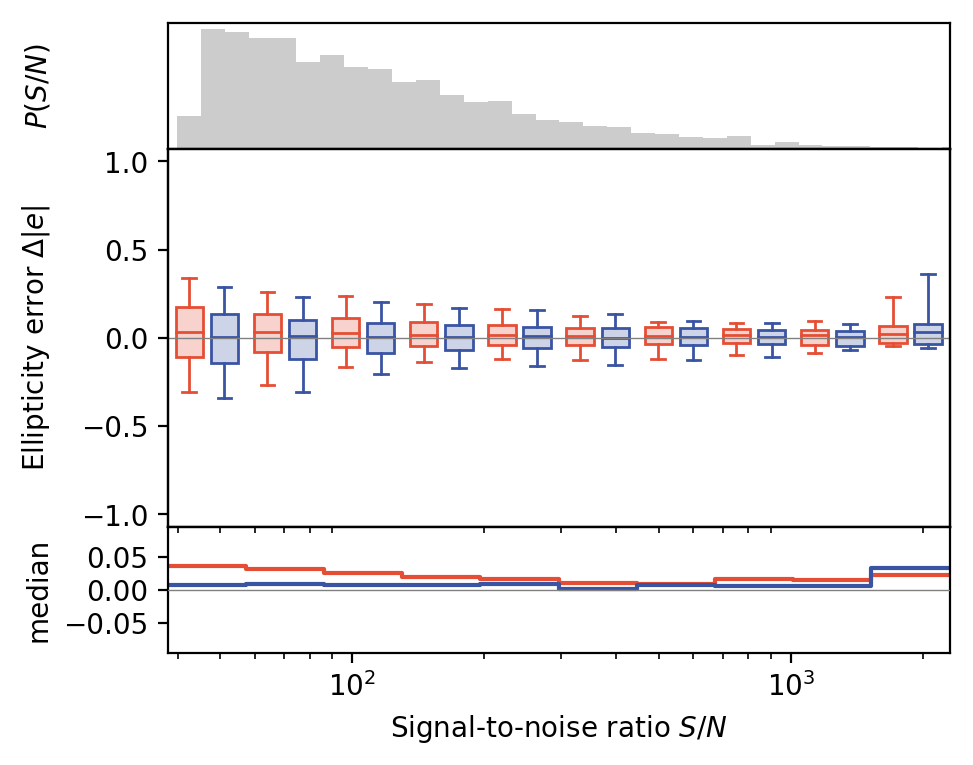

In [34]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'snr_r', y = 'e_error_reg', z = 'exp',
              xlim = (38, 2300),
              ylim = (-1.07, 1.07),
              ylim2= (-0.095, 0.095),
              x_scale = 'log',
              legend = ['weighting', 'no_weighting'],#, 'LSST pipeline'
              x_label='Signal-to-noise ratio $S/N$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(S/N)$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15,0.95]),#, 0.95
              nbins = 10)
fig.savefig('imgs/e_snr_weighting.pdf')

In [ ]:
np.mean(data[])

In [15]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 + ['pipeline']*10

x = 10

In [16]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][:+x])/np.mean(df_stat[param][10:10+x]) ]))

mean for each exp: [0.019922169922870357, 0.008967871901181085]
improvement between each exp: [2.2215047385151174]


16190
[1 2]
0 1
1 2


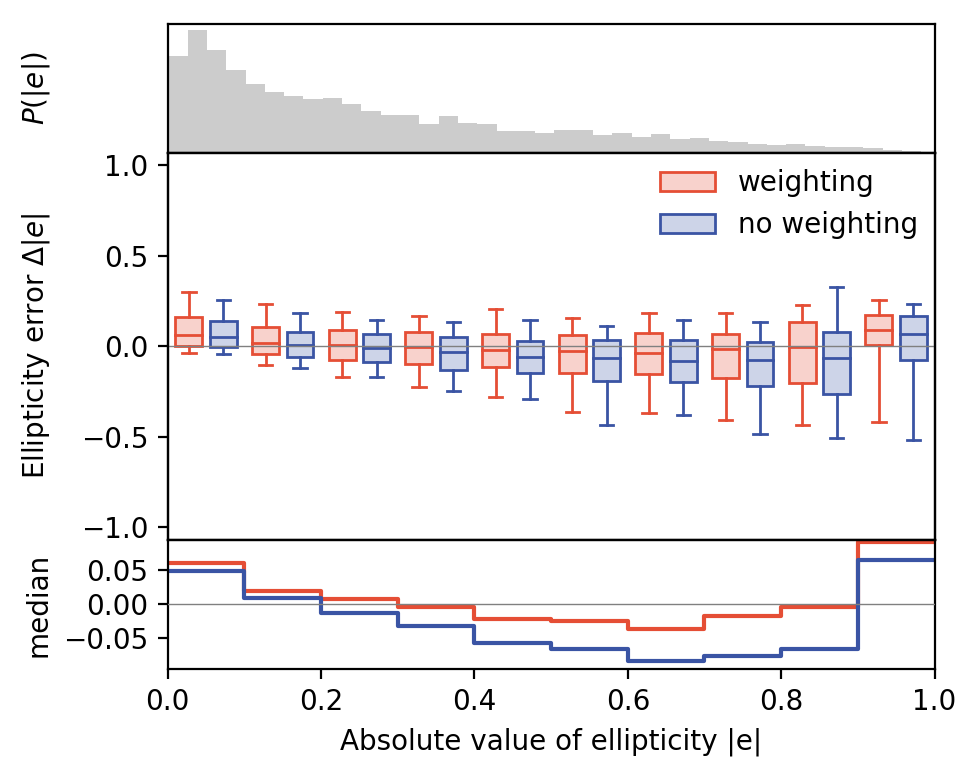

In [35]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'e_in', y = 'e_error_reg', z = 'exp',
              xlim = (0, 1),
              ylim = (-1.07, 1.07),
              ylim2= (-0.095, 0.095),
              x_scale = 'linear',
              legend = ['weighting', 'no weighting'],#, 'LSST pipeline'
              x_label='Absolute value of ellipticity |e|', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(|e|)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15,0.95]),
              nbins = 10)

fig.savefig('imgs/e_e_weighting.pdf')

In [18]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 + ['pipeline']*10

x = 10

In [19]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][:+x])/np.mean(df_stat[param][10:10+x]) ]))

mean for each exp: [0.028583618667079702, 0.05148451982489223]
improvement between each exp: [0.5551886035705011]


## Comparison with DebVAder and LSST

In [9]:
df_no_psf = pd.read_csv('data/df_vae_dc2_no_psf_noisy_i.csv', encoding = 'utf-8')

In [10]:
#df_no_psf.info()

In [54]:
part_1 = pd.read_csv('data/df_param_from_vae_1.csv', encoding = 'utf-8')
part_2 = pd.read_csv('data/df_param_from_vae_2.csv', encoding = 'utf-8')
part_3 = pd.read_csv('data/df_param_from_vae_3.csv', encoding = 'utf-8')
part_4 = pd.read_csv('data/df_param_from_vae_4.csv', encoding = 'utf-8')

df_plot_weighting = pd.concat([part_1,part_2, part_3, part_4], ignore_index = True)

part_1 = pd.read_csv('data/df_param_from_vae_no_weighting_1.csv', encoding = 'utf-8')
part_2 = pd.read_csv('data/df_param_from_vae_no_weighting_2.csv', encoding = 'utf-8')
part_3 = pd.read_csv('data/df_param_from_vae_no_weighting_3.csv', encoding = 'utf-8')
part_4 = pd.read_csv('data/df_param_from_vae_no_weighting_4.csv', encoding = 'utf-8')

df_plot_no_weighting = pd.concat([part_1,part_2, part_3, part_4], ignore_index = True)

In [55]:
df = pd.DataFrame()

d = pd.DataFrame()
d['e1_weighting'] = df_plot_weighting['e1_out_mean']
d['e2_weighting'] = df_plot_weighting['e2_out_mean']
d['e1_std_weighting'] = df_plot_weighting['e1_out_std']
d['e2_std_weighting'] = df_plot_weighting['e2_out_std']
d['e1_no_weighting'] = df_plot_no_weighting['e1_out_mean']
d['e2_no_weighting'] = df_plot_no_weighting['e2_out_mean']
d['e1_std_no_weighting'] = df_plot_no_weighting['e1_out_std']
d['e2_std_no_weighting'] = df_plot_no_weighting['e2_out_std']
d['e1_in'] = -e1
d['e2_in'] = e2
d['e_in'] = np.sqrt(d['e1_in']**2+d['e2_in']**2)

df['e_1'] = pd.concat([d['e1_weighting'],df_no_psf['e1_hsm_regauss'],data['e1_hsm_regauss']], ignore_index = True)
df['e_2'] = pd.concat([d['e2_weighting'],df_no_psf['e2_hsm_regauss'],data['e2_hsm_regauss']], ignore_index = True)
df['e'] = pd.concat([np.sqrt(d['e1_no_weighting']**2+d['e2_no_weighting']**2),np.sqrt(df_no_psf['e1_out_reg']**2+df_no_psf['e2_out_reg']**2),np.sqrt(data['e1_hsm_regauss']**2+data['e2_hsm_regauss']**2)], ignore_index = True)
df['e_in'] = pd.concat([d['e_in'],d['e_in'],d['e_in']], ignore_index = True)
df['e_error_reg'] = df['e']-df['e_in']

df['blendedness'] = pd.concat([data['blendedness'],data['blendedness'],data['blendedness']], ignore_index = True)
df['snr_r'] = pd.concat([data['snr_r'],data['snr_r'],data['snr_r']], ignore_index = True)

df['exp'] = [1]*10000+[2]*10000+[3]*10000

In [56]:
df_plot_2 = df[df['blendedness']>0]

24245
[1 2 3]
0 1
1 2
2 3


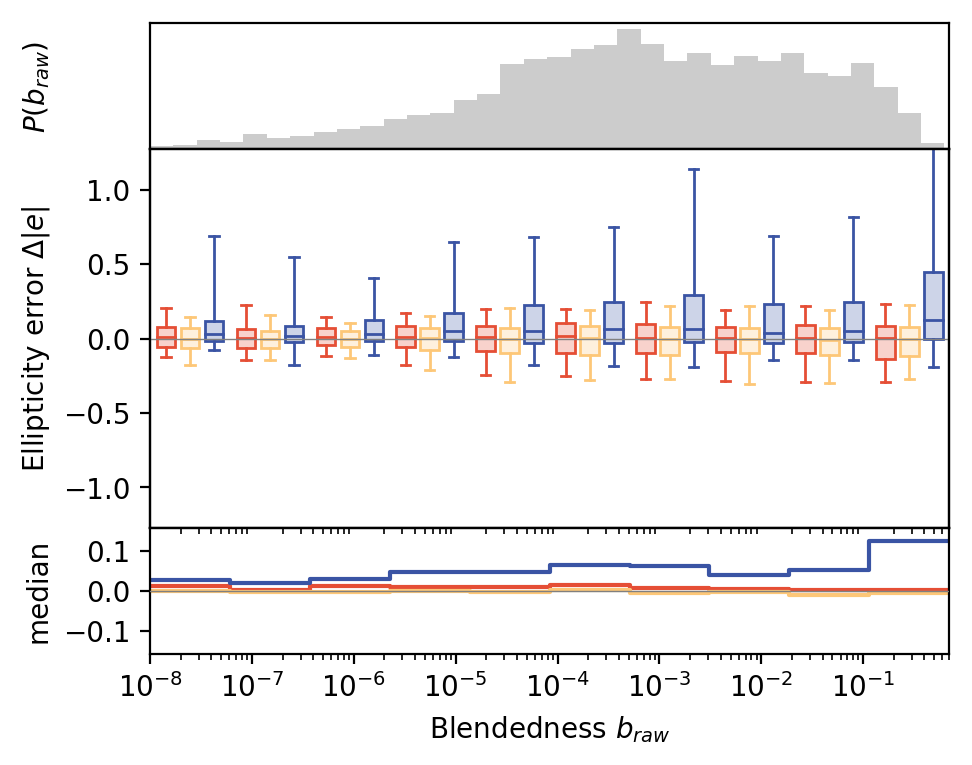

In [57]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'blendedness', y = 'e_error_reg', z = 'exp',
              xlim = (1e-8, 0.7),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['parameters estimation\nfrom VAE encoder', 'DebVAder', 'LSST pipeline'],
              x_label='Blendedness $b_{raw}$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(b_{raw})$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.15,0.35, 0.95]),
              nbins = 10)

fig.savefig('imgs/e_blend_dc2_from_vae_comparison.pdf')

In [39]:
len(np.where(df_plot_2['blendedness']>0.42)[0])

66

In [37]:
10**(-0.375)

0.4216965034285822

In [26]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 + ['debvae']*10 + ['pipeline']*10

x = 10

In [52]:
df_stat

,median_shear,q1_shear,q3_shear,whislo_shear,whishi_shear,stats_names
0,0.017235,0.030422,0.084135,0.111101,0.241685,network
1,0.005922,0.044246,0.075809,0.098389,0.244195,network
2,0.022641,0.031182,0.079128,0.095221,0.157546,network
3,0.020317,0.043231,0.102410,0.139236,0.202850,network
4,0.024578,0.059602,0.106901,0.221424,0.223696,network
5,0.029807,0.061469,0.129073,0.206039,0.256584,network
6,0.024053,0.070263,0.139045,0.227794,0.275284,network
7,0.023573,0.061559,0.109796,0.264535,0.249558,network
8,0.014315,0.071790,0.107237,0.272134,0.234004,network
9,0.019813,0.101161,0.126910,0.240815,0.221076,network


In [30]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x]),np.mean(df_stat[param][20:20+x]) ]))
print('improvement between each exp: '+str([np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][:+x]), np.mean(df_stat[param][20:20+x])/np.mean(df_stat[param][:+x]) ]))

mean for each exp: [0.007026599536507888, 0.0038565975559280473, 0.051497621612620226]
improvement between each exp: [0.5488568881562755, 7.328953549302989]


24245
[1 2 3]
0 1
1 2
2 3


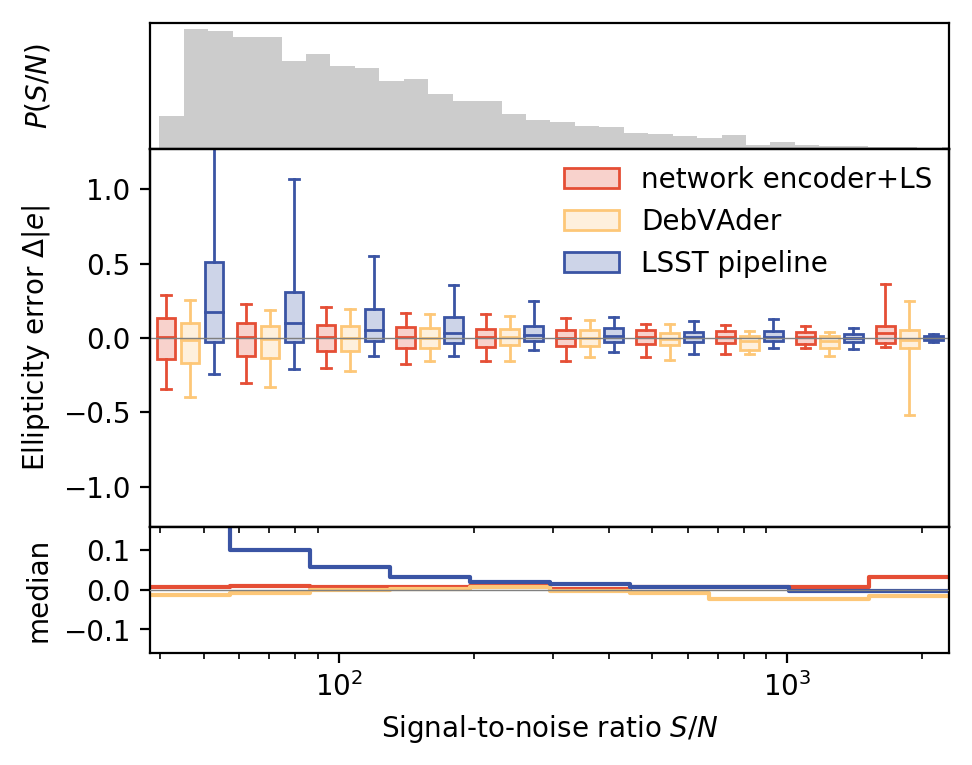

In [31]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_2, x = 'snr_r', y = 'e_error_reg', z = 'exp',
              xlim = (38, 2300),
              ylim = (-1.27, 1.27),
              ylim2= (-0.158, 0.158),
              x_scale = 'log',
              legend = ['network encoder+LS', 'DebVAder', 'LSST pipeline'],
              x_label='Signal-to-noise ratio $S/N$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(S/N)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.15,0.35, 0.95]),
              nbins = 10)
fig.savefig('imgs/e_snr_dc2_from_vae_comparison.pdf')

In [32]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
#df_stat['median_mag'] = np.abs(median_mag)
#df_stat['q1_mag'] = np.abs(q1_mag)
#df_stat['q3_mag'] = np.abs(q3_mag)
#df_stat['whislo_mag'] = np.abs(whislo_mag)
#df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['network']*10 + ['debvae']*10 + ['pipeline']*10

x = 10

In [33]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x]),np.mean(df_stat[param][20:20+x]) ]))
print('improvement between each exp: '+str([np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][:+x]), np.mean(df_stat[param][20:20+x])/np.mean(df_stat[param][:+x]) ]))

mean for each exp: [0.008967871901181085, 0.00993204158610259, 0.041320463821371126]
improvement between each exp: [1.107513766425959, 4.607610844210336]
